# Spectral analysis with the Fourier Transform

This tutorial demonstrates how to use the Fourier Transform methods in **earthkit-transforms** to analyse a timeseries in the frequency domain. We will:

1. compute the forward FFT of an hourly timeseries with `temporal.fft`,
2. inspect the power spectrum and identify the dominant (diurnal) cycle,
3. centre the spectrum with `fftshift`,
4. apply a simple low-pass filter and reconstruct a smoothed signal with `temporal.ifft`, and
5. verify that the forward and inverse transforms round-trip.

The transforms use the `fft` extension of the array namespace of the input data (the Python array API standard), so they run on the native backend of the data and return `xarray` objects.

Text(0.5, 1.0, 'Hourly 2m temperature at Reading')

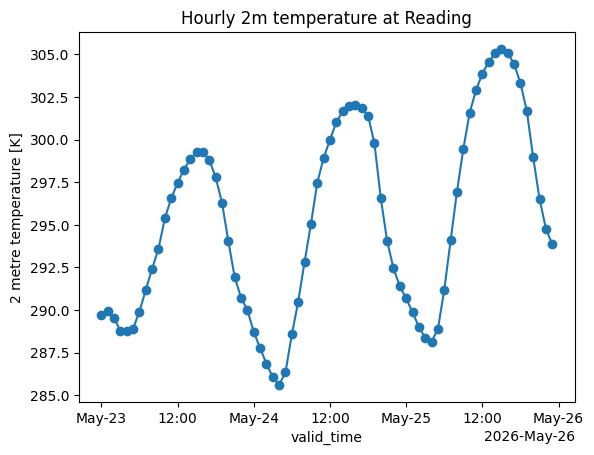

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from earthkit import data as ekd
from earthkit import transforms as ekt

# Hourly 2m temperature timeseries (72 hourly steps over 3 days) for two locations
ds = ekd.from_source("sample", "era5-timeseries-multiple.nc").to_xarray()
da = ds["t2m"].sel(location="Reading")

da.plot.line(x="valid_time", marker="o")
plt.title("Hourly 2m temperature at Reading")

## 1. Forward transform

`temporal.fft` detects the time dimension (`valid_time`) automatically and returns a complex-valued result indexed by a `frequency` dimension. Because the data are sampled hourly, the frequency coordinate is derived in Hz (cycles per second).

In [2]:
spectrum = ekt.temporal.fft(da)

spectrum

<xarray.DataArray 't2m' (frequency: 72)> Size: 576B
array([ 2.1254309e+04+0.0000000e+00j,  3.6181873e+01+8.3899078e+01j,
        1.8603952e+01+3.0636444e+01j, -1.9632404e+02+1.7992714e+02j,
        1.4326304e-01-1.8276188e+01j,  2.1387093e-02-3.5564790e+00j,
        1.5857482e+00+7.8525548e+00j, -8.0988111e+00-1.5550503e-01j,
       -9.4715452e+00+3.8258581e+00j,  1.0177716e+01-1.7595097e+01j,
        3.9469767e-01+5.0195365e+00j, -6.0290465e+00+3.9161768e+00j,
        4.1107635e+00-3.0908978e+00j, -1.7498523e+00+1.9973781e+00j,
       -1.5209463e+00+3.6424193e-01j, -4.9151093e-01+2.5865140e+00j,
       -3.2336328e+00+1.4347422e+00j, -8.6006445e-01+6.3981169e-01j,
       -4.4917297e+00+5.6923523e+00j, -6.9665194e-01+1.0354474e+00j,
       -2.8036752e+00+8.2415718e-01j, -2.4032340e+00+1.9318168e+00j,
       -1.5208218e+00+3.7614647e-01j, -3.4489987e+00+6.1524749e-01j,
       -2.9255829e+00-4.9863592e-01j, -2.0512412e+00+1.5625035e+00j,
       -2.7773783e+00+9.0367144e-01j, -1.7438781e+00+6.6997933e-01j,
       -2.3840063e+00+1.4095925e+00j, -1.4071045e+00+4.2337486e-01j,
       -2.3490539e+00+3.8001978e-01j, -1.9792778e+00+1.1325877e+00j,
       -1.9649117e+00+8.0021866e-02j, -2.6341197e+00+1.8611387e+00j,
       -1.6150200e+00+3.7647539e-01j, -2.0705647e+00+2.7284950e-01j,
       -1.4873657e+00+0.0000000e+00j, -2.0705647e+00-2.7284950e-01j,
       -1.6150200e+00-3.7647539e-01j, -2.6341197e+00-1.8611387e+00j,
       -1.9649117e+00-8.0021866e-02j, -1.9792778e+00-1.1325877e+00j,
       -2.3490539e+00-3.8001978e-01j, -1.4071045e+00-4.2337486e-01j,
       -2.3840063e+00-1.4095925e+00j, -1.7438781e+00-6.6997933e-01j,
       -2.7773783e+00-9.0367144e-01j, -2.0512412e+00-1.5625035e+00j,
       -2.9255829e+00+4.9863592e-01j, -3.4489987e+00-6.1524749e-01j,
       -1.5208218e+00-3.7614647e-01j, -2.4032340e+00-1.9318168e+00j,
       -2.8036752e+00-8.2415718e-01j, -6.9665194e-01-1.0354474e+00j,
       -4.4917297e+00-5.6923523e+00j, -8.6006445e-01-6.3981169e-01j,
       -3.2336328e+00-1.4347422e+00j, -4.9151093e-01-2.5865140e+00j,
       -1.5209463e+00-3.6424193e-01j, -1.7498523e+00-1.9973781e+00j,
        4.1107635e+00+3.0908978e+00j, -6.0290465e+00-3.9161768e+00j,
        3.9469767e-01-5.0195365e+00j,  1.0177716e+01+1.7595097e+01j,
       -9.4715452e+00-3.8258581e+00j, -8.0988111e+00+1.5550503e-01j,
        1.5857482e+00-7.8525548e+00j,  2.1387093e-02+3.5564790e+00j,
        1.4326304e-01+1.8276188e+01j, -1.9632404e+02-1.7992714e+02j,
        1.8603952e+01-3.0636444e+01j,  3.6181873e+01-8.3899078e+01j],
      dtype=complex64)
Coordinates:
  * frequency   (frequency) float64 576B 0.0 3.858e-06 ... -7.716e-06 -3.858e-06
    location    <U9 36B 'Reading'
    latitude    float64 8B 51.5
    longitude   float64 8B -1.0
    utc_offset  timedelta64[s] 8B 01:00:00
Attributes: (12/30)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    long_name:                                2 metre temperature
    standard_name:                            unknown
    units:                                    K

## 2. Power spectrum and the dominant cycle

The squared amplitude of each frequency component gives the power spectrum. We keep the positive frequencies and convert each frequency (Hz) to a period in hours to make the result easier to interpret.

Dominant period: 24.0 hours


Text(0.5, 1.0, 'Power spectrum')

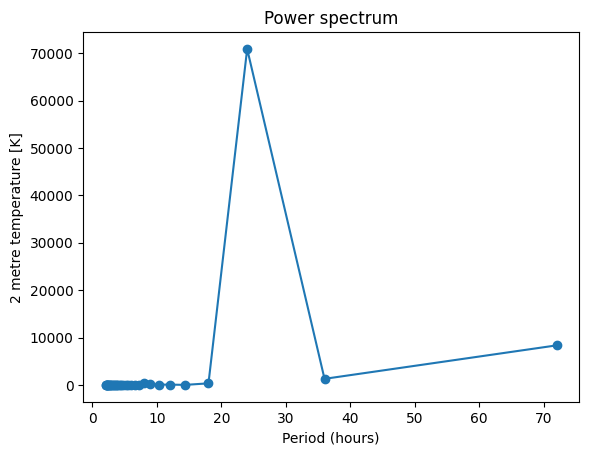

In [3]:
positive = spectrum.where(spectrum["frequency"] > 0, drop=True)
power = (np.abs(positive) ** 2).rename("power")

# Convert frequency in Hz to a period in hours
period_hours = 1.0 / (positive["frequency"] * 3600.0)
power = power.assign_coords(period_hours=("frequency", period_hours.data))

dominant_period = float(power["period_hours"][power.argmax("frequency")].item())
print(f"Dominant period: {dominant_period:.1f} hours")

power.plot.line(x="period_hours", marker="o")
plt.xlabel("Period (hours)")
plt.title("Power spectrum")

The strongest peak is close to 24 hours, reflecting the diurnal cycle of near-surface temperature.

## 3. Centre the spectrum with `fftshift`

The raw FFT output orders the frequencies from zero upwards and then wraps around to the negative frequencies. `fftshift` reorders the data (and its frequency coordinate) so that the zero-frequency component is in the centre, which is often more convenient for plotting. The generic spectrum helpers live in the `earthkit.transforms._fourier` module.

Text(0.5, 1.0, 'Amplitude spectrum (zero frequency centred)')

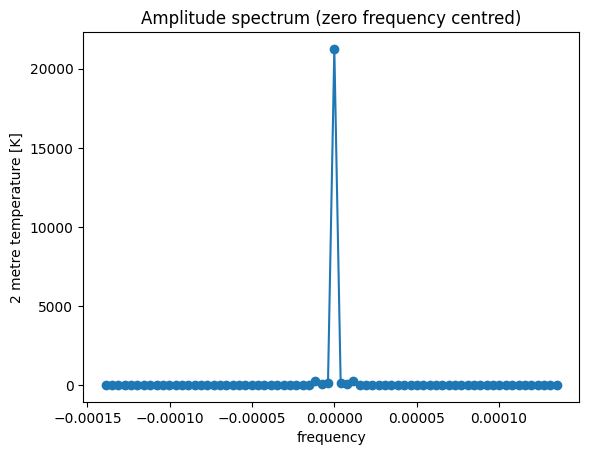

In [4]:
shifted = ekt._fourier.fftshift(spectrum, dim="frequency")

np.abs(shifted).plot.line(x="frequency", marker="o")
plt.title("Amplitude spectrum (zero frequency centred)")

## 4. Low-pass filter and inverse transform

We can filter in the frequency domain and transform back to the time domain. Here we keep only the low-frequency components (periods of 12 hours or longer) by setting the higher frequencies to zero, then reconstruct a smoothed signal with `temporal.ifft`.

Text(0.5, 1.0, 'Low-pass filtered temperature')

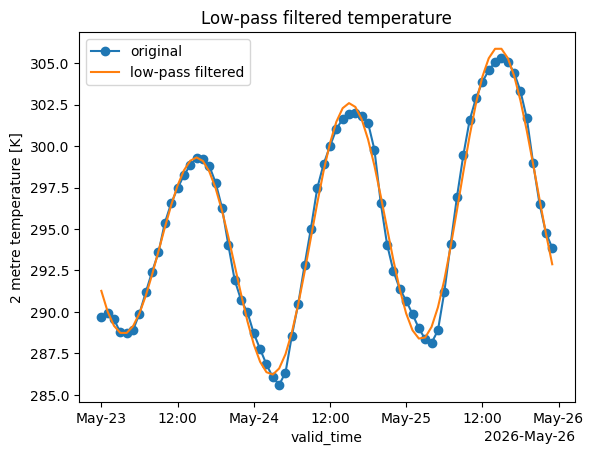

In [5]:
# Keep components with a period of 12 hours or longer
cutoff_hz = 1.0 / (12 * 3600.0)
filtered = spectrum.where(np.abs(spectrum["frequency"]) <= cutoff_hz, 0)

smoothed = ekt.temporal.ifft(filtered, time_dim="valid_time", time_coord=da["valid_time"].values).real

da.plot.line(x="valid_time", marker="o", label="original")
smoothed.plot.line(x="valid_time", label="low-pass filtered")
plt.legend()
plt.title("Low-pass filtered temperature")

## 5. Round-trip verification

Applying the inverse transform to the full spectrum recovers the original signal (up to floating-point precision).

In [6]:
restored = ekt.temporal.ifft(spectrum, time_dim="valid_time", time_coord=da["valid_time"].values).real

print("Maximum absolute difference:", float(np.abs(restored - da).max()))

Maximum absolute difference: 6.103515625e-05


## Beyond the time dimension

The same transforms are available generically in the `earthkit.transforms._fourier` module, where the dimension is specified explicitly (for example `earthkit.transforms._fourier.fft(dataarray, dim="longitude")`). That module also provides the real-valued transforms (`rfft`/`irfft`), the n-dimensional transforms (`fftn`/`ifftn`/`rfftn`/`irfftn`), the sample-frequency helpers (`fftfreq`/`rfftfreq`) and the spectrum shifts (`fftshift`/`ifftshift`) from the Python array API standard.